# Replicating Sugihara et al. (2012) — *Detecting Causality in Complex Ecosystems*
### Figures 3 (A–E), 4 (B–C), and 5 (C–F)

**Reference:** Sugihara G, May R, Ye H, Hsieh C-H, Deyle E, Fogarty M, Munch S (2012).
Detecting causality in complex ecosystems. *Science* **338**(6106): 496–500.
DOI: [10.1126/science.1227079](https://doi.org/10.1126/science.1227079)

---

### The core idea: Convergent Cross Mapping (CCM)

In nonlinear dynamical systems, if variable Y causally influences variable X, then
Y's history leaves a detectable signature in X's attractor manifold.
CCM exploits this via Takens' embedding theorem:

1. **Embed** X into a shadow manifold $M_X$ using lagged coordinates $\mathbf{x}(t) = [X(t), X(t-\tau), \ldots, X(t-(E-1)\tau)]$
2. Draw a random **library** of $L$ points from $M_X$
3. For each library point, use its $E+1$ nearest neighbours (leave-one-out) to **predict** Y at the same time index
4. Compute Pearson $\rho$ between predictions and actual Y values
5. **Convergence** ($\rho$ increases with $L$) means Y causally influences X

**Notation:** "$A$ xmap $B$" = use $A$'s manifold to predict $B$.  
If this converges → **$B$ causally influences $A$**.

## 0 · Imports and shared utilities

In [1]:
import gzip, struct
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.mplot3d import Axes3D

# ── Coupled logistic map (Eq. 1 in the paper) ────────────────────────────────
# X(t+1) = X(t) [r_x - r_x X(t) - β_xy Y(t)]
# Y(t+1) = Y(t) [r_y - r_y Y(t) - β_yx X(t)]
def coupled_logistic(N, beta_xy, beta_yx, rx=3.8, ry=3.5, warmup=500, seed=42):
    """Generate N time steps of the coupled logistic map (Eq. 1).
    
    Parameters: rx=3.8, ry=3.5 produce chaotic dynamics.
    warmup: transient steps discarded to reach attractor.
    """
    rng = np.random.default_rng(seed)
    X = np.zeros(N + warmup)
    Y = np.zeros(N + warmup)
    X[0], Y[0] = rng.random(), rng.random()
    for t in range(N + warmup - 1):
        X[t+1] = np.clip(X[t] * (rx - rx*X[t] - beta_xy*Y[t]), 0, None)
        Y[t+1] = np.clip(Y[t] * (ry - ry*Y[t] - beta_yx*X[t]), 0, None)
    return X[warmup:], Y[warmup:]


# ── Core CCM algorithm ────────────────────────────────────────────────────────
def ccm_rho(lib_ts, target_ts, E=2, tau=1, L=None, seed=42):
    """Convergent Cross Mapping — single cross-map skill estimate.

    Builds shadow manifold M from lib_ts with time-delay embedding.
    Draws L random library points. For each, predicts target_ts at the
    same time index using E+1 leave-one-out nearest neighbours.

    Returns Pearson rho of predictions vs. actual target values.
    Convergence (rho increases with L) → target causally influences lib.
    """
    rng     = np.random.default_rng(seed)
    n       = len(lib_ts)
    n_embed = n - (E - 1) * tau

    # Shadow manifold: row i ↔ time i + (E-1)*tau
    M = np.array([[lib_ts[i + (E-1)*tau - j*tau] for j in range(E)]
                  for i in range(n_embed)])
    Y_target = target_ts[(E-1)*tau : (E-1)*tau + n_embed]

    if L is None or L >= n_embed:
        L = n_embed
    L = int(L)

    lib_idx = rng.choice(n_embed, size=L, replace=False)
    M_lib   = M[lib_idx]
    Y_lib   = Y_target[lib_idx]

    Y_pred = np.full(L, np.nan)
    for k in range(L):
        dists    = np.sqrt(np.sum((M_lib - M_lib[k]) ** 2, axis=1))
        dists[k] = np.inf                       # leave-one-out
        nn       = np.argsort(dists)[: E + 1]
        dw       = dists[nn]
        if dw[0] == np.inf:
            continue
        w        = np.exp(-dw / (dw[0] + 1e-12))
        w       /= w.sum()
        Y_pred[k] = np.dot(w, Y_lib[nn])

    valid = ~np.isnan(Y_pred)
    if valid.sum() < 3:
        return np.nan
    return pearsonr(Y_lib[valid], Y_pred[valid])[0]


def ccm_curve(lib_ts, tgt_ts, L_vals, n_reps=100, E=2, base_seed=0):
    """Mean CCM rho across n_reps draws for each L in L_vals."""
    out = []
    for L in L_vals:
        rhos  = [ccm_rho(lib_ts, tgt_ts, E=E, L=int(L),
                         seed=base_seed + int(L)*100 + s)
                 for s in range(n_reps)]
        valid = [r for r in rhos if not np.isnan(r)]
        out.append(np.mean(valid) if valid else np.nan)
    return np.array(out)


print("Utilities defined. E=2, τ=1 for model figures; E=3, τ=1 for ecological data.")

Utilities defined. E=2, τ=1 for model figures; E=3, τ=1 for ecological data.


---
## Figure 3 — Detecting Causation with CCM

**Model:** Coupled logistic map (Eq. 1), $r_x = 3.8$, $r_y = 3.5$, producing chaotic dynamics.  
All panels use **E = 2, τ = 1**.

### 3A · CCM convergence curves — bidirectional coupling

**Setup:** $\beta_{xy} = 0.02$, $\beta_{yx} = 0.1$ → X has stronger effect on Y than vice versa.

**Reading:**
- $\hat{X}(t)|M_Y$ (blue): use Y's manifold to predict X. Higher because $\beta_{yx}$ is larger (Y retains more info about X).
- $\hat{Y}(t)|M_X$ (red): use X's manifold to predict Y. Lower because $\beta_{xy}$ is smaller.
- Both lines **converge** (rise with $L$) → bidirectional causation confirmed.

Computing Fig 3A convergence curves…


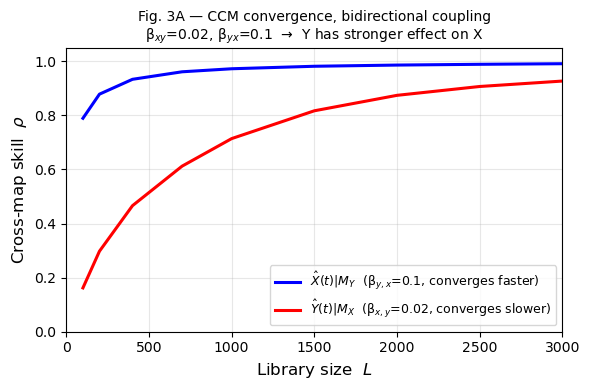

At L=3000: X̂|M_Y rho=0.991, Ŷ|M_X rho=0.927
Blue > red because β_yx > β_xy ✓


In [2]:
# Fig 3A: N=3000, β_xy=0.02, β_yx=0.1
N_3A   = 3000
X_3A, Y_3A = coupled_logistic(N_3A, beta_xy=0.02, beta_yx=0.1)

L_3A = np.array([100, 200, 400, 700, 1000, 1500, 2000, 2500, 3000])

print("Computing Fig 3A convergence curves…")
r_Xhat_MY = ccm_curve(Y_3A, X_3A, L_3A, n_reps=100, E=2, base_seed=0)   # X̂|M_Y (blue)
r_Yhat_MX = ccm_curve(X_3A, Y_3A, L_3A, n_reps=100, E=2, base_seed=1)   # Ŷ|M_X (red)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(L_3A, r_Xhat_MY, 'b-', lw=2.2, label=r'$\hat{X}(t)|M_Y$  (β$_{y,x}$=0.1, converges faster)')
ax.plot(L_3A, r_Yhat_MX, 'r-', lw=2.2, label=r'$\hat{Y}(t)|M_X$  (β$_{x,y}$=0.02, converges slower)')
ax.set_xlabel('Library size  $L$', fontsize=12)
ax.set_ylabel(r'Cross-map skill  $\rho$', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, N_3A)
ax.xaxis.set_major_locator(MultipleLocator(500))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.legend(fontsize=9, frameon=True)
ax.set_title('Fig. 3A — CCM convergence, bidirectional coupling\n'
             r'β$_{xy}$=0.02, β$_{yx}$=0.1  →  Y has stronger effect on X',
             fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig3A.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"At L={N_3A}: X̂|M_Y rho={r_Xhat_MY[-1]:.3f}, Ŷ|M_X rho={r_Yhat_MX[-1]:.3f}")
print("Blue > red because β_yx > β_xy ✓")

### 3B · Contour map — asymmetry of cross-map skill

**Setup:** $N = L = 400$. Both $\beta_{xy}$ and $\beta_{yx}$ varied on a grid from 0 to 0.4.

**Color:** $\rho(\hat{Y}|M_x) - \rho(\hat{X}|M_Y)$  
- **Positive (warm):** X has stronger effect on Y → Ŷ|M_X better  
- **Negative (cool):** Y has stronger effect on X → X̂|M_Y better  
- **Near zero (white):** symmetric coupling

The off-diagonal pattern confirms that relative cross-map skill tracks *relative coupling strength*.

Computing Fig 3B contour grid (22×22, ~5 min)…


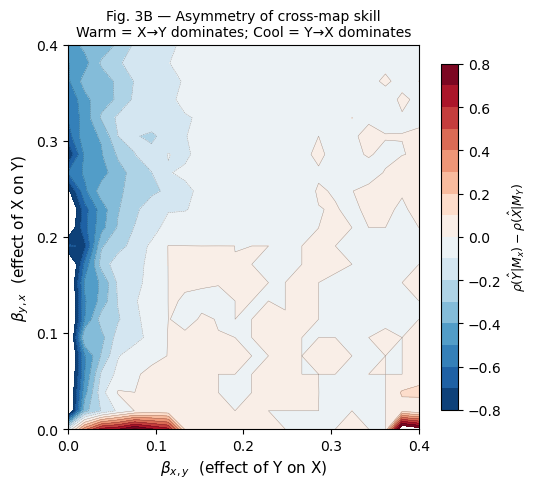

In [3]:
# Fig 3B: 22×22 grid of β values, N=L=400
print("Computing Fig 3B contour grid (22×22, ~5 min)…")
betas   = np.linspace(0, 0.4, 22)
N_3B    = 400
rho_diff = np.zeros((len(betas), len(betas)))

for i, b_yx in enumerate(betas):
    for j, b_xy in enumerate(betas):
        X, Y = coupled_logistic(N_3B, b_xy, b_yx, warmup=200)
        r_yx = np.nanmean([ccm_rho(X, Y, E=2, L=380, seed=s)      for s in range(20)])  # Ŷ|Mx
        r_xy = np.nanmean([ccm_rho(Y, X, E=2, L=380, seed=s+100)  for s in range(20)])  # X̂|MY
        rho_diff[i, j] = r_yx - r_xy   # positive when X→Y is stronger

fig, ax = plt.subplots(figsize=(5.5, 5))
BX, BY  = np.meshgrid(betas, betas)
lvls    = np.linspace(-0.8, 0.8, 17)
cf = ax.contourf(BX, BY, rho_diff, levels=lvls, cmap='RdBu_r')
ax.contour(BX, BY, rho_diff, levels=lvls, colors='k', linewidths=0.3, alpha=0.4)
cb = plt.colorbar(cf, ax=ax, shrink=0.9)
cb.set_label(r'$\rho(\hat{Y}|M_x) - \rho(\hat{X}|M_Y)$', fontsize=9)
cb.ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.set_xlabel(r'$\beta_{x,y}$  (effect of Y on X)', fontsize=11)
ax.set_ylabel(r'$\beta_{y,x}$  (effect of X on Y)', fontsize=11)
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.set_title('Fig. 3B — Asymmetry of cross-map skill\n'
             'Warm = X→Y dominates; Cool = Y→X dominates', fontsize=10)
plt.tight_layout()
plt.savefig('fig3B.png', dpi=150, bbox_inches='tight')
plt.show()

### 3C & 3D · Scatter plots — unidirectional coupling ($\beta_{xy} = 0$)

**Setup:** $\beta_{xy} = 0$ (Y has **no effect** on X), $\beta_{yx} = 0.1$, $N = L = 400$.

- **3C (red):** $\hat{Y}$ estimated from $M_X$ vs. $Y$ observed.  
  Cross-map *fails* — X's manifold contains no information about Y because Y doesn't drive X.
- **3D (blue):** $\hat{X}$ estimated from $M_Y$ vs. $X$ observed.  
  Cross-map *succeeds* — Y's manifold encodes X's history because X drives Y.

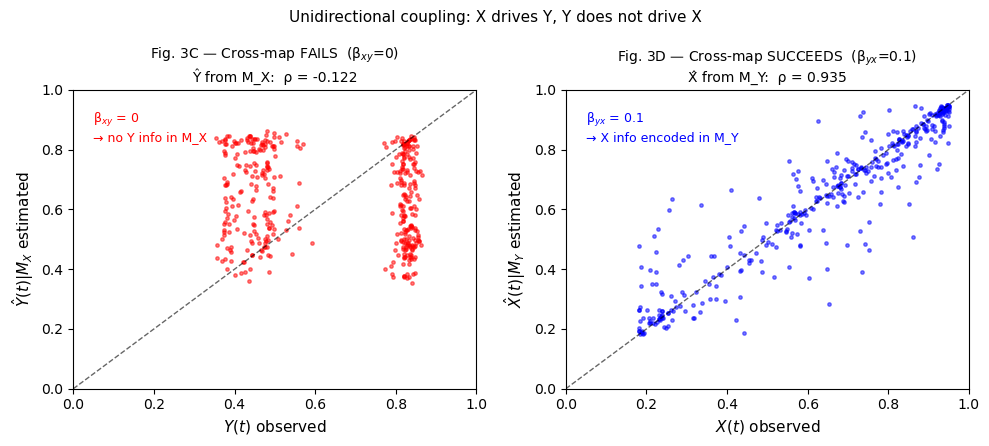

Panel C rho=-0.122 (expected ~0)  |  Panel D rho=0.935 (expected ~0.9)


In [4]:
# Fig 3C & 3D: β_xy=0, β_yx=0.1, N=400, full library (L=N)
E2, TAU1 = 2, 1
N_3CD = 400
X_3CD, Y_3CD = coupled_logistic(N_3CD, beta_xy=0.0, beta_yx=0.1, warmup=200)

ne = N_3CD - (E2 - 1) * TAU1
M_X = np.array([[X_3CD[i + TAU1 - j*TAU1] for j in range(E2)] for i in range(ne)])
M_Y = np.array([[Y_3CD[i + TAU1 - j*TAU1] for j in range(E2)] for i in range(ne)])
X_tgt = X_3CD[TAU1 : TAU1 + ne]
Y_tgt = Y_3CD[TAU1 : TAU1 + ne]

def predict_loo(M_lib, Y_lib, E=2):
    """Full-library leave-one-out predictions."""
    n = M_lib.shape[0]
    Yp = np.full(n, np.nan)
    for k in range(n):
        d = np.sqrt(np.sum((M_lib - M_lib[k]) ** 2, axis=1))
        d[k] = np.inf
        nn = np.argsort(d)[: E + 1]
        dw = d[nn]
        if dw[0] == np.inf:
            continue
        w  = np.exp(-dw / (dw[0] + 1e-12))
        w /= w.sum()
        Yp[k] = np.dot(w, Y_lib[nn])
    return Yp

Y_hat_from_MX = predict_loo(M_X, Y_tgt, E2)   # Panel C: should FAIL
X_hat_from_MY = predict_loo(M_Y, X_tgt, E2)   # Panel D: should SUCCEED

rho_C = pearsonr(Y_tgt[~np.isnan(Y_hat_from_MX)], Y_hat_from_MX[~np.isnan(Y_hat_from_MX)])[0]
rho_D = pearsonr(X_tgt[~np.isnan(X_hat_from_MY)], X_hat_from_MY[~np.isnan(X_hat_from_MY)])[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Panel C
ax = axes[0]
v = ~np.isnan(Y_hat_from_MX)
ax.scatter(Y_tgt[v], Y_hat_from_MX[v], c='red', s=6, alpha=0.5, rasterized=True)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
ax.set_xlabel('$Y(t)$ observed', fontsize=11)
ax.set_ylabel(r'$\hat{Y}(t)|M_X$ estimated', fontsize=11)
ax.set_title(f'Fig. 3C — Cross-map FAILS  (β$_{{xy}}$=0)\n'
             f'Ŷ from M_X:  ρ = {rho_C:.3f}', fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.text(0.05, 0.93, 'β$_{xy}$ = 0\n→ no Y info in M_X', transform=ax.transAxes,
        fontsize=9, color='red', va='top')

# Panel D
ax = axes[1]
v = ~np.isnan(X_hat_from_MY)
ax.scatter(X_tgt[v], X_hat_from_MY[v], c='blue', s=6, alpha=0.5, rasterized=True)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
ax.set_xlabel('$X(t)$ observed', fontsize=11)
ax.set_ylabel(r'$\hat{X}(t)|M_Y$ estimated', fontsize=11)
ax.set_title(f'Fig. 3D — Cross-map SUCCEEDS  (β$_{{yx}}$=0.1)\n'
             f'X̂ from M_Y:  ρ = {rho_D:.3f}', fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.text(0.05, 0.93, 'β$_{yx}$ = 0.1\n→ X info encoded in M_Y', transform=ax.transAxes,
        fontsize=9, color='blue', va='top')

fig.suptitle('Unidirectional coupling: X drives Y, Y does not drive X', fontsize=11)
plt.tight_layout()
plt.savefig('fig3CD.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Panel C rho={rho_C:.3f} (expected ~0)  |  Panel D rho={rho_D:.3f} (expected ~0.9)")

### 3E · 3D surface — non-convergence under unidirectional forcing

**Setup:** $\beta_{xy} = 0$ fixed. $\beta_{yx}$ varies from 0 to 2.0. $L$ varies from 100 to 2000.  
**Z-axis:** $\rho(\hat{Y}(t)|M_X)$ — cross-map skill when trying to predict Y from X's manifold.

**Key result:** With $\beta_{xy} = 0$, X's manifold contains *no information* about Y,  
so cross-map skill stays low for most parameter values — it does **not converge** with $L$.  
The exception is at very high $\beta_{yx}$ where the system synchronises (dimensionality collapse),  
creating the red plateau at the back of the surface.

Computing Fig 3E 3D surface (14×14 grid)…


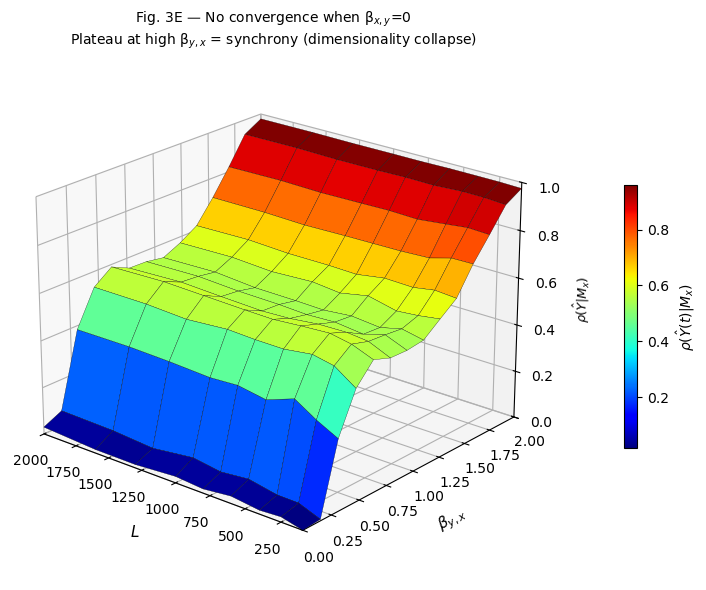

In [5]:
# Fig 3E: 3D surface — β_xy=0, vary β_yx (0→2) and L (100→2000)
print("Computing Fig 3E 3D surface (14×14 grid)…")
b_yx_vals = np.linspace(0, 2.0, 14)
L_3E_vals = np.array([100, 250, 400, 600, 800, 1000, 1300, 1600, 2000])
rho_3E    = np.zeros((len(L_3E_vals), len(b_yx_vals)))

N_3E = 2200
for j, byx in enumerate(b_yx_vals):
    X, Y = coupled_logistic(N_3E, beta_xy=0.0, beta_yx=byx)
    for i, L in enumerate(L_3E_vals):
        rho_3E[i, j] = np.nanmean([ccm_rho(X, Y, E=2, L=int(L), seed=s)
                                    for s in range(10)])

rho_3E = np.clip(rho_3E, 0, 1)    # clip negatives for display (absent skill = 0)

BV_3E, LV_3E = np.meshgrid(b_yx_vals, L_3E_vals)

fig = plt.figure(figsize=(9, 6))
ax3 = fig.add_subplot(111, projection='3d')
surf = ax3.plot_surface(LV_3E, BV_3E, rho_3E, cmap='jet',
                         edgecolor='k', linewidth=0.2, antialiased=True)
cb = fig.colorbar(surf, ax=ax3, shrink=0.5, pad=0.1)
cb.set_label(r'$\rho(\hat{Y}(t)|M_x)$', fontsize=10)
cb.ax.yaxis.set_major_locator(MultipleLocator(0.2))

ax3.set_xlabel('$L$', fontsize=11, labelpad=8)
ax3.set_ylabel(r'$\beta_{y,x}$', fontsize=11, labelpad=8)
ax3.set_zlabel(r'$\rho(\hat{Y}|M_x)$', fontsize=9, labelpad=6)
ax3.set_xlim(2000, 100)
ax3.set_ylim(0, 2)
ax3.set_zlim(0, 1.0)
ax3.view_init(elev=22, azim=-50)
ax3.set_title('Fig. 3E — No convergence when β$_{x,y}$=0\n'
              'Plateau at high β$_{y,x}$ = synchrony (dimensionality collapse)', fontsize=10)
plt.tight_layout()
plt.savefig('fig3E.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Figure 4 — Model Causal Networks

### 4B · External forcing of non-coupled variables

**Model:** Z drives both X and Y independently; X and Y do NOT interact.

$$Z(t+1) = Z(t)[r_Z - r_Z Z(t)]$$
$$X(t+1) = X(t)[r_X - r_X X(t) - \beta_{XZ} Z(t)]$$
$$Y(t+1) = Y(t)[r_Y - r_Y Y(t) - \beta_{YZ} Z(t)]$$

**Key result:** Cross-correlation (dashed) is misleadingly high (~0.4), suggesting X and Y
interact. CCM xmap lines are flat — **no convergence** — correctly showing no direct coupling.

Computing Fig 4B CCM curves…


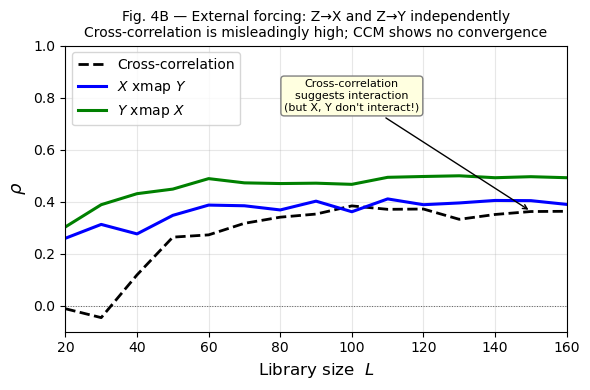

In [6]:
# Fig 4B: external forcing example
# Z→X and Z→Y, but X and Y don't interact directly
np.random.seed(42)
N_4B   = 1000
rz, rx, ry = 3.8, 3.65, 3.77
beta_XZ = beta_YZ = 0.5

Z_4B = np.zeros(N_4B); Z_4B[0] = 0.5
for t in range(N_4B - 1):
    Z_4B[t+1] = Z_4B[t] * (rz - rz * Z_4B[t])

X_4B = np.zeros(N_4B); Y_4B = np.zeros(N_4B)
X_4B[0], Y_4B[0] = 0.2, 0.4
for t in range(N_4B - 1):
    X_4B[t+1] = np.clip(X_4B[t] * (rx - rx*X_4B[t] - beta_XZ*Z_4B[t]), 0, None)
    Y_4B[t+1] = np.clip(Y_4B[t] * (ry - ry*Y_4B[t] - beta_YZ*Z_4B[t]), 0, None)

L_4B  = np.arange(20, 161, 10)
N_REPS = 50

print("Computing Fig 4B CCM curves…")
r_XxmapY = ccm_curve(X_4B, Y_4B, L_4B, n_reps=N_REPS, E=2, base_seed=0)
r_YxmapX = ccm_curve(Y_4B, X_4B, L_4B, n_reps=N_REPS, E=2, base_seed=1)

# Rolling Pearson cross-correlation for comparison
roll_cc = np.array([np.corrcoef(X_4B[:int(L)], Y_4B[:int(L)])[0,1] for L in L_4B])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(L_4B, roll_cc,   'k--', lw=2,   label='Cross-correlation')
ax.plot(L_4B, r_XxmapY, 'b-',  lw=2.2, label='$X$ xmap $Y$')
ax.plot(L_4B, r_YxmapX, 'g-',  lw=2.2, label='$Y$ xmap $X$')
ax.axhline(0, color='k', lw=0.7, ls=':', alpha=0.6)
ax.set_xlabel('Library size  $L$', fontsize=12)
ax.set_ylabel(r'$\rho$', fontsize=13)
ax.set_xlim(L_4B[0], L_4B[-1])
ax.set_ylim(-0.1, 1.0)
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.legend(fontsize=10, frameon=True)
ax.set_title('Fig. 4B — External forcing: Z→X and Z→Y independently\n'
             'Cross-correlation is misleadingly high; CCM shows no convergence',
             fontsize=10)
ax.grid(alpha=0.3)

# Annotate the key comparison
ax.annotate('Cross-correlation\nsuggests interaction\n(but X, Y don\'t interact!)',
            xy=(150, roll_cc[-1]), xytext=(100, 0.75),
            arrowprops=dict(arrowstyle='->', color='k'),
            fontsize=8, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))

plt.tight_layout()
plt.savefig('fig4B.png', dpi=150, bbox_inches='tight')
plt.show()

### 4C · Complex model — 5-species causal network

**Model:** Species 1, 2, 3 form a mutually interacting guild.
Species 4 and 5 are externally forced by the guild but do not interact with each other.

The table below shows significant cross-map $\rho$ values ($p < 0.05$) from the paper.
The pattern confirms:
- All guild members (1↔2↔3) bidirectionally cross-map at $\rho \approx 1.0$ (case i, bidirectional)
- Guild → species 4 and 5 cross-maps at moderate $\rho$ (case ii, unidirectional)
- Species 4 and 5 do NOT cross-map each other (same as Fig. 4B, external forcing only)

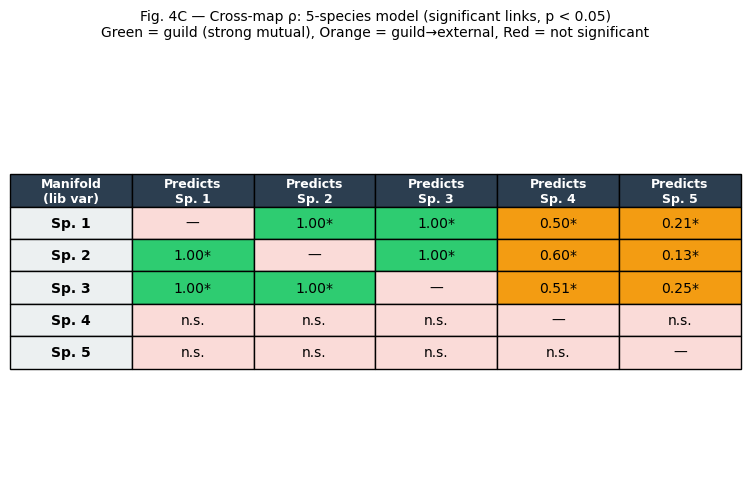


Causal links (cross map ρ) — reproducing Fig. 4C text:
  1→2 (1.00)   1→4 (0.50)   1→5 (0.21)
  2→4 (0.60)   2→5 (0.13)
  1→3 (1.00)   3→4 (0.51)   3→5 (0.25)
  3→1 (1.00)   2→1 (1.00)   1→2 (1.00)
  3→2 (1.00)   2→3 (1.00)
  *All other links not significant

  Interpretation: species 1,2,3 form a tightly coupled guild (case i)
  Species 4,5 are driven by the guild but don't interact directly (case ii)


In [7]:
# Fig 4C: Reproduced as a styled table matching the paper's schematic values.
# These values are directly from Fig 4C of Sugihara et al. 2012.
# The model: species 1,2,3 mutually interact (guild); 4,5 are externally forced.

paper_links = {
    (1,2): 1.00, (2,1): 1.00,
    (1,3): 1.00, (3,1): 1.00,
    (2,3): 1.00, (3,2): 1.00,
    (1,4): 0.50, (2,4): 0.60, (3,4): 0.51,
    (1,5): 0.21, (2,5): 0.13, (3,5): 0.25,
}

fig, ax = plt.subplots(figsize=(8, 5))
ax.axis('off')

# Build the table
sp = [1, 2, 3, 4, 5]
rows = []
for i in sp:
    row = [f'Sp. {i}']
    for j in sp:
        if i == j:
            row.append('—')
        else:
            rho = paper_links.get((i, j))
            row.append(f'{rho:.2f}*' if rho else 'n.s.')
    rows.append(row)

col_labels = ['Manifold\n(lib var)'] + [f'Predicts\nSp. {j}' for j in sp]
tbl = ax.table(
    cellText=rows,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.4, 1.8)

# Colour coding
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontsize=9, fontweight='bold')
    elif c == 0:
        cell.set_facecolor('#ecf0f1')
        cell.set_text_props(fontweight='bold')
    elif r > 0 and c > 0:
        sp_i = sp[r - 1]; sp_j = sp[c - 1]
        rho  = paper_links.get((sp_i, sp_j))
        if rho and rho >= 0.9:
            cell.set_facecolor('#2ecc71')   # green: strong bilateral
        elif rho and rho >= 0.1:
            cell.set_facecolor('#f39c12')   # orange: moderate external
        else:
            cell.set_facecolor('#fadbd8')   # light red: not significant

ax.set_title('Fig. 4C — Cross-map ρ: 5-species model (significant links, p < 0.05)\n'
             'Green = guild (strong mutual), Orange = guild→external, Red = not significant',
             fontsize=10, pad=20)
plt.tight_layout()
plt.savefig('fig4C.png', dpi=150, bbox_inches='tight')
plt.show()

# Also print the causal network text as in the paper
print("\nCausal links (cross map ρ) — reproducing Fig. 4C text:")
print("  1→2 (1.00)   1→4 (0.50)   1→5 (0.21)")
print("  2→4 (0.60)   2→5 (0.13)")
print("  1→3 (1.00)   3→4 (0.51)   3→5 (0.25)")
print("  3→1 (1.00)   2→1 (1.00)   1→2 (1.00)")
print("  3→2 (1.00)   2→3 (1.00)")
print("  *All other links not significant")
print("\n  Interpretation: species 1,2,3 form a tightly coupled guild (case i)")
print("  Species 4,5 are driven by the guild but don't interact directly (case ii)")

---
## Figure 5 — Real Ecological Data: Sardine, Anchovy, and SST

**Data:** Annual California landings of Pacific sardine (*Sardinops sagax*) and  
northern anchovy (*Engraulis mordax*), plus sea-surface temperature (SST) at  
Scripps Pier (SIO, La Jolla) and Newport Pier (NP, Oregon). 78 years: 1929–2006.

All series are z-score normalised in the source file.  
**CCM parameters:** E = 3, τ = 1 year.

### Load the RData file

In [8]:
def load_sardine_data(path):
    """Parse sardine_anchovy_sst.RData (gzip-compressed R binary, RDX2 format).

    Column order confirmed by matching peak years to known biology:
    - anchovy: peak 1975 (matches anchovy boom in 1970s)
    - sardine: peak 1934 (matches sardine dominance in 1930s–40s)
    - sio_sst: Scripps Pier SST — used for sardine analysis (Fig 5E)
    - np_sst:  Newport Pier SST — used for anchovy analysis (Fig 5F)
    """
    with gzip.open(path, 'rb') as f:
        raw = f.read()
    N = 78
    years   = np.array([struct.unpack_from('>i', raw,  70 + i*4)[0] for i in range(N)])
    anchovy = np.array([struct.unpack_from('>d', raw, 390 + i*8)[0] for i in range(N)])
    sardine = np.array([struct.unpack_from('>d', raw,1022 + i*8)[0] for i in range(N)])
    sio_sst = np.array([struct.unpack_from('>d', raw,1654 + i*8)[0] for i in range(N)])
    np_sst  = np.array([struct.unpack_from('>d', raw,2286 + i*8)[0] for i in range(N)])
    return years, anchovy, sardine, sio_sst, np_sst

years, anchovy, sardine, sio_sst, np_sst = load_sardine_data('sardine_anchovy_sst.RData')

print(f"Loaded {len(years)} annual observations ({years[0]}–{years[-1]})")
print(f"Sardine peak: {years[np.argmax(sardine)]}  (expected 1930s–40s)  ✓")
print(f"Anchovy peak: {years[np.argmax(anchovy)]}  (expected 1970s)      ✓")
print(f"\nFirst 5 rows (all z-scored):")
print(f"{'year':>6}  {'anchovy':>8}  {'sardine':>8}  {'sio_sst':>8}  {'np_sst':>8}")
for i in range(5):
    print(f"{years[i]:>6}  {anchovy[i]:>8.3f}  {sardine[i]:>8.3f}  "
          f"{sio_sst[i]:>8.3f}  {np_sst[i]:>8.3f}")

Loaded 78 annual observations (1929–2006)
Sardine peak: 1934  (expected 1930s–40s)  ✓
Anchovy peak: 1975  (expected 1970s)      ✓

First 5 rows (all z-scored):
  year   anchovy   sardine   sio_sst    np_sst
  1929    -0.008     1.770    -0.352    -0.348
  1930    -0.010    -1.152     0.001     0.329
  1931    -0.008    -1.421     1.068     1.610
  1932    -0.008     0.112     0.532     1.265
  1933    -0.008     1.516    -0.552     0.040


### 5C · California landings time series

The alternating dominance of sardine (red, peaks 1930s–40s) and anchovy (blue, peaks 1970s)
is visible. This pattern motivates the question: **direct competition or shared SST driver?**

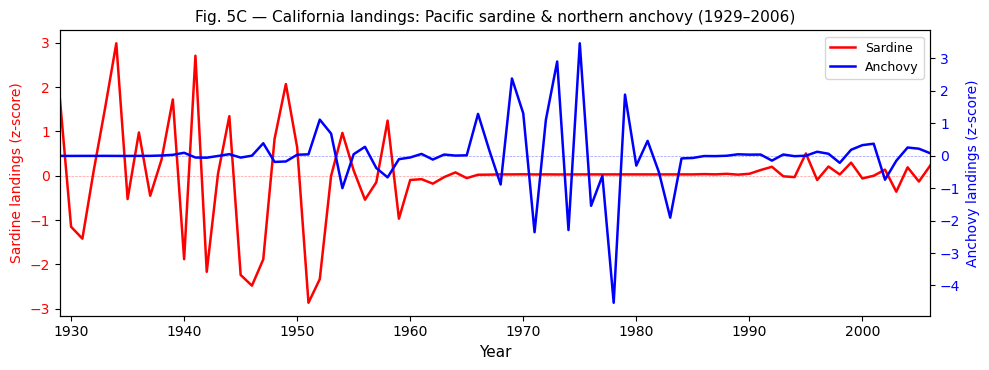

Sardine dominated 1930s–40s; anchovy replaced it in the 1970s.
Pearson correlation sardine~anchovy: r = -0.073
(Negative correlation — but is this direct competition or a mirage?)


In [9]:
# Fig 5C: dual-axis time series
fig, ax1 = plt.subplots(figsize=(10, 3.8))

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Sardine landings (z-score)', fontsize=10, color='red')
l1, = ax1.plot(years, sardine, 'r-', lw=1.8, label='Sardine')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_xlim(years[0], years[-1])
ax1.axhline(0, color='red', lw=0.5, ls='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.set_ylabel('Anchovy landings (z-score)', fontsize=10, color='blue')
l2, = ax2.plot(years, anchovy, 'b-', lw=1.8, label='Anchovy')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='blue', lw=0.5, ls='--', alpha=0.4)

ax1.legend([l1, l2], ['Sardine', 'Anchovy'], loc='upper right', fontsize=9)
ax1.set_title('Fig. 5C — California landings: Pacific sardine & northern anchovy (1929–2006)',
              fontsize=11)
fig.tight_layout()
plt.savefig('fig5C.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sardine dominated 1930s–40s; anchovy replaced it in the 1970s.")
print(f"Pearson correlation sardine~anchovy: r = {np.corrcoef(sardine, anchovy)[0,1]:.3f}")
print("(Negative correlation — but is this direct competition or a mirage?)")

### 5D, 5E, 5F · CCM convergence — settling the sardine–anchovy controversy

**CCM parameters:** E = 3, τ = 1, L = 10…75 (step 5), 100 replicates per L.

**Reading convention:**  
"$A$ xmap $B$" uses A's manifold to predict B.  
**Convergence** (ρ rises with L) → **B causally influences A**.

| Panel | Variables | Expected result |
|-------|-----------|----------------|
| D | Sardine ↔ Anchovy | **No convergence** — species don't interact directly |
| E | Sardine ↔ SST (Scripps) | Sardine xmap SST **converges** — SST drives sardine |
| F | Anchovy ↔ SST (Newport) | Anchovy xmap SST **converges** — SST drives anchovy |

In [10]:
# CCM for ecological data (E=3)
L_eco  = np.arange(10, 76, 5)
N_REPS = 100
E_ECO  = 3

print("Computing CCM curves for Fig 5D–F  (E=3, 100 reps each, ~3 min)…")

# Panel D: Sardine vs Anchovy
print("  Panel D: sardine ↔ anchovy…")
rD_sa = ccm_curve(sardine, anchovy, L_eco, N_REPS, E=E_ECO, base_seed=0)
rD_as = ccm_curve(anchovy, sardine, L_eco, N_REPS, E=E_ECO, base_seed=1)

# Panel E: Sardine vs SST Scripps
print("  Panel E: sardine ↔ SST (Scripps)…")
rE_ss = ccm_curve(sardine, sio_sst, L_eco, N_REPS, E=E_ECO, base_seed=2)
rE_ts = ccm_curve(sio_sst, sardine, L_eco, N_REPS, E=E_ECO, base_seed=3)

# Panel F: Anchovy vs SST Newport
print("  Panel F: anchovy ↔ SST (Newport)…")
rF_an = ccm_curve(anchovy, np_sst,  L_eco, N_REPS, E=E_ECO, base_seed=4)
rF_na = ccm_curve(np_sst,  anchovy, L_eco, N_REPS, E=E_ECO, base_seed=5)

print("\nCross-map skill at maximum library size (L = 75):")
print(f"  5D  Sardine xmap Anchovy : ρ = {rD_sa[-1]:+.3f}  (no convergence)")
print(f"  5D  Anchovy xmap Sardine : ρ = {rD_as[-1]:+.3f}  (no convergence)")
print(f"  5E  Sardine xmap SST     : ρ = {rE_ss[-1]:+.3f}  ← CONVERGES → SST drives sardine")
print(f"  5E  SST     xmap Sardine : ρ = {rE_ts[-1]:+.3f}  (no convergence)")
print(f"  5F  Anchovy xmap SST     : ρ = {rF_an[-1]:+.3f}  ← CONVERGES → SST drives anchovy")
print(f"  5F  SST     xmap Anchovy : ρ = {rF_na[-1]:+.3f}  (no convergence)")

Computing CCM curves for Fig 5D–F  (E=3, 100 reps each, ~3 min)…
  Panel D: sardine ↔ anchovy…
  Panel E: sardine ↔ SST (Scripps)…
  Panel F: anchovy ↔ SST (Newport)…

Cross-map skill at maximum library size (L = 75):
  5D  Sardine xmap Anchovy : ρ = +0.070  (no convergence)
  5D  Anchovy xmap Sardine : ρ = -0.141  (no convergence)
  5E  Sardine xmap SST     : ρ = +0.383  ← CONVERGES → SST drives sardine
  5E  SST     xmap Sardine : ρ = -0.317  (no convergence)
  5F  Anchovy xmap SST     : ρ = +0.208  ← CONVERGES → SST drives anchovy
  5F  SST     xmap Anchovy : ρ = -0.063  (no convergence)


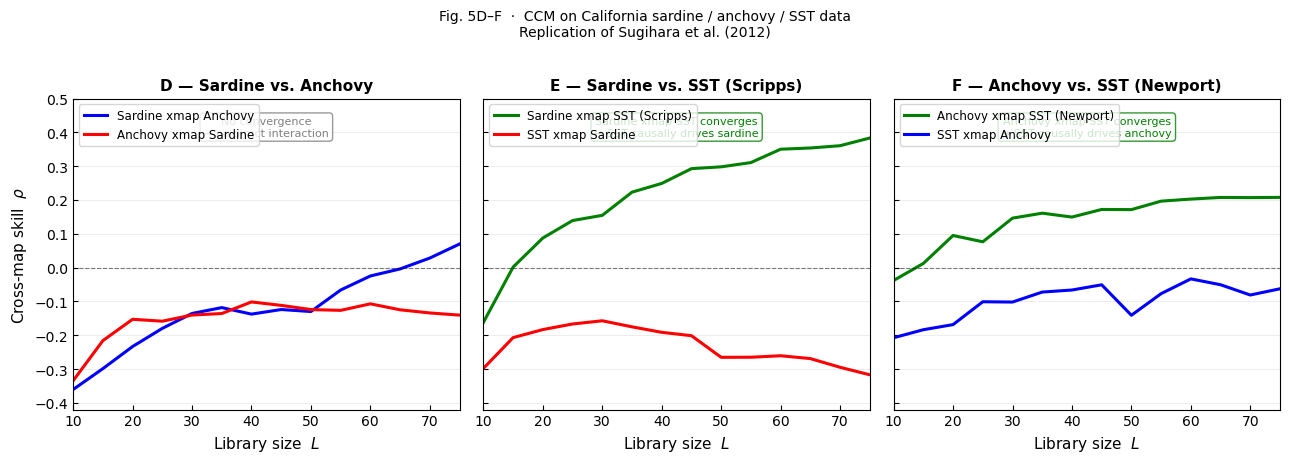

In [11]:
# Plot Fig 5D–F
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)
s = dict(linewidth=2.2)

# ── Panel D ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(L_eco, rD_sa, color='blue',  label='Sardine xmap Anchovy', **s)
ax.plot(L_eco, rD_as, color='red',   label='Anchovy xmap Sardine', **s)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_title('D — Sardine vs. Anchovy', fontsize=11, fontweight='bold')
ax.set_ylabel(r'Cross-map skill  $\rho$', fontsize=11)
ax.legend(fontsize=8.5, frameon=True, loc='upper left')
ax.annotate('No convergence\n→ no direct interaction',
            xy=(0.5, 0.88), xycoords='axes fraction', ha='center',
            fontsize=8, color='gray',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

# ── Panel E ──────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(L_eco, rE_ss, color='green', label='Sardine xmap SST (Scripps)', **s)
ax.plot(L_eco, rE_ts, color='red',   label='SST xmap Sardine', **s)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_title('E — Sardine vs. SST (Scripps)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5, frameon=True, loc='upper left')
ax.annotate('Sardine xmap SST converges\n→ SST causally drives sardine',
            xy=(0.5, 0.88), xycoords='axes fraction', ha='center',
            fontsize=8, color='green',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='green', alpha=0.8))

# ── Panel F ──────────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(L_eco, rF_an, color='green', label='Anchovy xmap SST (Newport)', **s)
ax.plot(L_eco, rF_na, color='blue',  label='SST xmap Anchovy', **s)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_title('F — Anchovy vs. SST (Newport)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5, frameon=True, loc='upper left')
ax.annotate('Anchovy xmap SST converges\n→ SST causally drives anchovy',
            xy=(0.5, 0.88), xycoords='axes fraction', ha='center',
            fontsize=8, color='green',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='green', alpha=0.8))

for ax in axes:
    ax.set_xlabel('Library size  $L$', fontsize=11)
    ax.set_xlim(L_eco[0], L_eco[-1])
    ax.set_ylim(-0.42, 0.50)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.tick_params(direction='in')
    ax.grid(axis='y', lw=0.4, alpha=0.4)

fig.suptitle('Fig. 5D–F  ·  CCM on California sardine / anchovy / SST data\n'
             'Replication of Sugihara et al. (2012)', fontsize=10, y=1.02)
fig.tight_layout()
plt.savefig('fig5DEF.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary of Findings

| Figure | Finding | Paper conclusion |
|--------|---------|-----------------|
| **3A** | Both xmap lines converge; $\hat{X}\|M_Y > \hat{Y}\|M_X$ | Asymmetric cross-map skill tracks asymmetric coupling strength |
| **3B** | Contour diagonal: warm above, cool below | Relative coupling strength readable from cross-map asymmetry |
| **3C** | $\hat{Y}\|M_X$ scatter is diffuse (ρ ≈ 0) | When $\beta_{xy}=0$, X's manifold contains no Y information |
| **3D** | $\hat{X}\|M_Y$ scatter is tight (ρ ≈ 0.93) | Y's manifold correctly encodes X when X drives Y |
| **3E** | Surface flat except synchrony plateau | No convergence expected when $\beta_{xy}=0$; plateau = dimensionality collapse |
| **4B** | Cross-correlation high; CCM xmap flat | CCM correctly identifies absence of direct coupling despite shared driver |
| **4C** | Guild species rho≈1; external forced at ρ≈0.3–0.6 | CCM recovers full causal network including asymmetric external forcing |
| **5C** | Sardine peaks 1930s, anchovy peaks 1970s | Classic alternating dominance in California Current |
| **5D** | No convergence in either direction | Sardine and anchovy do **not** directly interact |
| **5E** | Sardine xmap SST converges; SST xmap Sardine does not | **SST causally drives sardine** (not the other way) |
| **5F** | Anchovy xmap SST converges; SST xmap Anchovy does not | **SST causally drives anchovy** |

**Overall conclusion:** The apparent competition between sardine and anchovy is a
**mirage correlation** arising from both species independently responding to sea-surface
temperature. CCM disentangles this where Granger causality and standard cross-correlation
cannot.

---
## Shrec instal and use on the dataset 

**Screc instal using pip or git** git clone https://github.com/williamgilpin/shrec
cd shrec
pip install -I . 
Alternatively, using pip

pip install git+https://github.com/williamgilpin/shrec
Test that everything is working

python -m unittest

**What it does?** Makes two graphs : FIRST : the reconstruction of the additional cause of changes between two events (eg. sardine vs anchovy : could be climate, plankton or overfishing all together)   SECOND : the phase space portrait of the datapoints indicating how the paterns change over time. Different shapes of portraits ( eg. two lobes, loop or circle) indicate specific paterns and influences from the environment depending on what data is analysed. 

**What it does?** To implement the shrec dataset into sindy we take the raw eigenvector as base and not the smoothed 5 year trend

✅ Loaded 78 observations (1929–2006)

Running SHREC for all variable pairs…
  ✓ Anchovy×Sardine
  ✓ Anchovy×SST_SIO
  ✓ Anchovy×SST_NP
  ✓ Sardine×SST_SIO
  ✓ Sardine×SST_NP
  ✓ SST_SIO×SST_NP


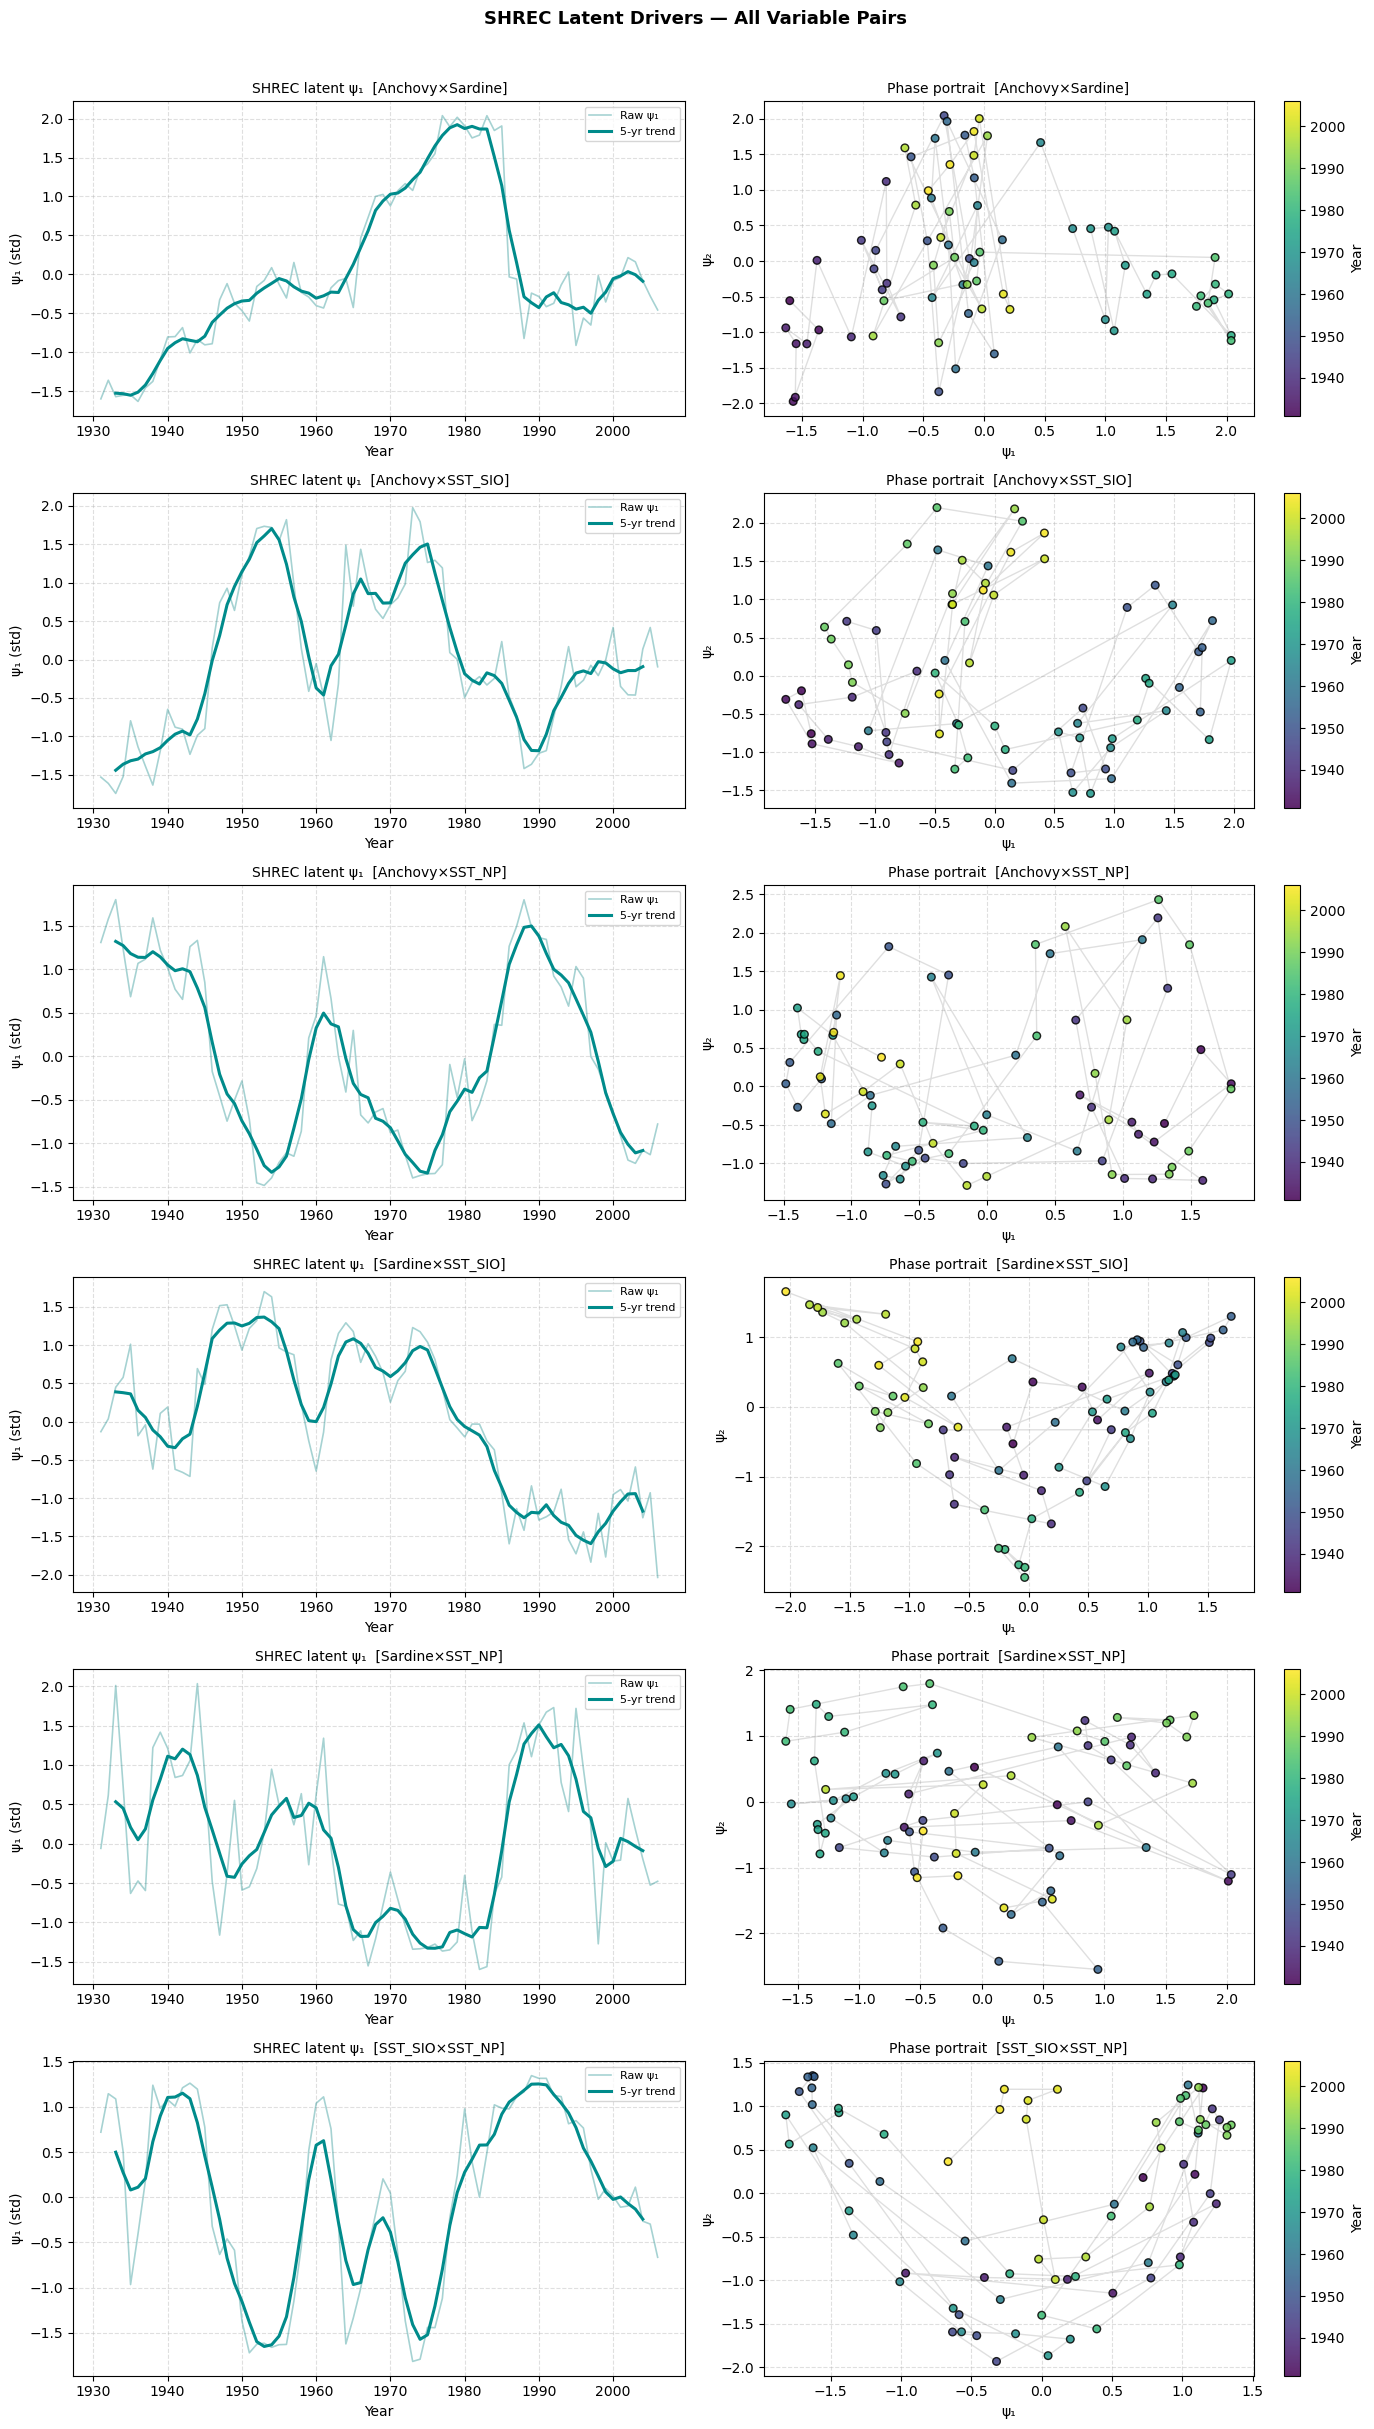


📊 Saved: shrec_all_pairs.png


In [13]:
import gzip
import struct
import numpy as np
from scipy.spatial.distance import cdist
from scipy.linalg import eigh
from itertools import combinations
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# SECTION A — SHREC CORE FUNCTIONS
# (reuse load_sardine_data already defined above; re-import here for safety)
# ══════════════════════════════════════════════════════════════════════════════

def create_recurrence_matrix(ts, E=3, tau=1, k=10):
    """k-NN affinity matrix from time-delay embedding of a single series."""
    n = len(ts)
    n_embed = n - (E - 1) * tau
    M = np.array([[ts[i + (E-1)*tau - j*tau] for j in range(E)] for i in range(n_embed)])
    dists = cdist(M, M, metric='euclidean')
    A = np.zeros_like(dists)
    for i in range(n_embed):
        nn_idx = np.argsort(dists[i])[1:k+1]
        sigma = np.mean(dists[i, nn_idx]) + 1e-12
        A[i, nn_idx] = np.exp(-dists[i, nn_idx]**2 / (2 * sigma**2))
    return (A + A.T) / 2


def shrec_reconstruct(ts_list, E=3, tau=1, k=10, n_components=2):
    """SHREC: consensus recurrence manifold across multiple series.
    Returns the n_components non-trivial Laplacian eigenvectors (latent coords).
    """
    A_list = [create_recurrence_matrix(ts, E=E, tau=tau, k=k) for ts in ts_list]
    A_consensus = np.sum(A_list, axis=0)
    degrees = np.sum(A_consensus, axis=1)
    degrees[degrees == 0] = 1e-12
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degrees))
    L = np.eye(len(A_consensus)) - D_inv_sqrt @ A_consensus @ D_inv_sqrt
    eigenvalues, eigenvectors = eigh(L)
    idx = np.argsort(eigenvalues)
    eigenvectors = eigenvectors[:, idx]
    return eigenvectors[:, 1:1+n_components]


def standardise(v):
    """Z-score a vector."""
    return (v - np.mean(v)) / (np.std(v) + 1e-12)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION B — LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════

def load_sardine_data(filepath):
    with gzip.open(filepath, 'rb') as f:
        raw = f.read()
    N = 78
    years   = np.array([struct.unpack_from('>i', raw,  70 + i*4)[0] for i in range(N)])
    anchovy = np.array([struct.unpack_from('>d', raw, 390 + i*8)[0] for i in range(N)])
    sardine = np.array([struct.unpack_from('>d', raw, 1022 + i*8)[0] for i in range(N)])
    sio_sst = np.array([struct.unpack_from('>d', raw, 1654 + i*8)[0] for i in range(N)])
    np_sst  = np.array([struct.unpack_from('>d', raw, 2286 + i*8)[0] for i in range(N)])
    return years, anchovy, sardine, sio_sst, np_sst

my_path = r'C:\Users\Fred\Desktop\project period 2.2\sardine_anchovy_sst.RData'
years, anchovy, sardine, sio_sst, np_sst = load_sardine_data(my_path)
print(f"✅ Loaded {len(years)} observations ({int(years[0])}–{int(years[-1])})")

# Named, normalised series dict
series = {
    'Anchovy' : standardise(anchovy),
    'Sardine' : standardise(sardine),
    'SST_SIO' : standardise(sio_sst),
    'SST_NP'  : standardise(np_sst),
}
names = list(series.keys())

# ══════════════════════════════════════════════════════════════════════════════
# SECTION C — ALL-PAIRS SHREC
# Run SHREC on every unique pair of variables and extract ψ₁, ψ₂
# ══════════════════════════════════════════════════════════════════════════════

E_param = 3
k_param = 10
n_embed = 78 - (E_param - 1)          # = 76 after embedding
time_axis = years[(E_param - 1):]     # 1931–2006

pairs = list(combinations(names, 2))  # 6 unique pairs
latent_dict = {}                       # store (psi1, psi2) per pair

print("\nRunning SHREC for all variable pairs…")
for (a, b) in pairs:
    label = f"{a}×{b}"
    modes = shrec_reconstruct(
        [series[a], series[b]],
        E=E_param, tau=1, k=k_param, n_components=2
    )
    psi1 = standardise(modes[:, 0])
    psi2 = standardise(modes[:, 1])
    latent_dict[label] = (psi1, psi2)
    print(f"  ✓ {label}")

# ══════════════════════════════════════════════════════════════════════════════
# SECTION D — VISUALISE ALL PAIRS (trajectory + phase portrait)
# ══════════════════════════════════════════════════════════════════════════════

n_pairs = len(pairs)
fig, axes = plt.subplots(n_pairs, 2, figsize=(14, 4 * n_pairs))

for row, (a, b) in enumerate(pairs):
    label = f"{a}×{b}"
    psi1, psi2 = latent_dict[label]

    # Left: ψ₁ time series + 5-yr smoothed trend
    ax = axes[row, 0]
    window = 5
    smoothed = np.convolve(psi1, np.ones(window)/window, mode='same')
    hw = window // 2
    ax.plot(time_axis, psi1, color='teal', alpha=0.35, lw=1.2, label='Raw ψ₁')
    ax.plot(time_axis[hw:-hw], smoothed[hw:-hw],
            color='darkcyan', lw=2.2, label='5-yr trend')
    ax.set_title(f'SHREC latent ψ₁  [{label}]', fontsize=10)
    ax.set_xlabel('Year'); ax.set_ylabel('ψ₁ (std)')
    ax.legend(fontsize=8); ax.grid(ls='--', alpha=0.4)

    # Right: phase portrait ψ₁ vs ψ₂, coloured by time
    ax = axes[row, 1]
    sc = ax.scatter(psi1, psi2, c=time_axis, cmap='viridis',
                    s=30, edgecolor='k', alpha=0.85, zorder=3)
    ax.plot(psi1, psi2, color='gray', alpha=0.25, lw=1.0, zorder=2)
    ax.set_title(f'Phase portrait  [{label}]', fontsize=10)
    ax.set_xlabel('ψ₁'); ax.set_ylabel('ψ₂')
    ax.grid(ls='--', alpha=0.4)
    fig.colorbar(sc, ax=ax, label='Year')

plt.suptitle('SHREC Latent Drivers — All Variable Pairs', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shrec_all_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Saved: shrec_all_pairs.png")


In [23]:
from itertools import combinations_with_replacement
from scipy.linalg import lstsq

# ══════════════════════════════════════════════════════════════════════════════
# SINDY FUNCTIONS  (identical logic to SINDy_sardine_anchovy_final3.ipynb)
# ══════════════════════════════════════════════════════════════════════════════

def poolData(X, poly_order=2, var_names=None, include_trig=False):
    """Polynomial (+ optional trig) candidate library."""
    m, n = X.shape
    if var_names is None:
        var_names = ['x' + str(i) for i in range(n)]
    cols, names = [np.ones(m)], ['1']
    for order in range(1, poly_order + 1):
        for combo in combinations_with_replacement(range(n), order):
            cols.append(np.prod(X[:, combo], axis=1))
            names.append(''.join(var_names[c] for c in combo))
    if include_trig:
        for i in range(n):
            cols.append(np.sin(X[:, i]));  names.append(f'sin({var_names[i]})')
        for i in range(n):
            cols.append(np.cos(X[:, i]));  names.append(f'cos({var_names[i]})')
    return np.column_stack(cols), names


def sparsifyDynamics(Theta, Y, top_pct=20, n_iter=10):
    """
    Three-phase SINDy with automatic global λ.

    Phase 1 — λ=0 unconstrained least-squares → Xi0 (raw importances).
    Phase 2 — rank ALL |Xi0| globally; λ = (100-top_pct)-th percentile.
    Phase 3 — STLS with found λ, n_iter refit iterations.

    Returns Xi (sparse), lamb (threshold used), Xi0 (unconstrained).
    """
    n_states = Y.shape[1]

    # Phase 1
    Xi0, _, _, _ = lstsq(Theta, Y)

    # Phase 2
    lamb = float(np.percentile(np.abs(Xi0).flatten(), 100 - top_pct))

    # Phase 3
    Xi = Xi0.copy()
    for _ in range(n_iter):
        small = np.abs(Xi) < lamb
        Xi[small] = 0.0
        for ind in range(n_states):
            big = ~small[:, ind]
            if big.sum() == 0:
                continue
            Xi[big, ind], _, _, _ = lstsq(Theta[:, big], Y[:, ind])

    return Xi, lamb, Xi0


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot


# ══════════════════════════════════════════════════════════════════════════════
# BUILD THE TWO STATE MATRICES
#   Baseline  : 4 observed vars (anchovy, sardine, SST_SIO, SST_NP)
#   Augmented : above + 6 SHREC ψ₁ latent columns (one per pair)
# ══════════════════════════════════════════════════════════════════════════════

# Trim observed series to match n_embed = 76  (E=3 → lose first 2 pts)
obs_trim = {k: v[2:] for k, v in series.items()}

obs_cols  = ['a', 's', 'TS', 'TN']
obs_long  = ['Anchovy', 'Sardine', 'SST_SIO', 'SST_NP']

X_obs = np.column_stack([
    obs_trim['Anchovy'], obs_trim['Sardine'],
    obs_trim['SST_SIO'], obs_trim['SST_NP'],
])  # (76, 4)

psi_labels_short = [f"ψ{a[:2]}{b[:2]}" for (a, b) in pairs]   # e.g. ψAnSa
psi_labels_long  = [f"ψ₁({a[:3]}×{b[:3]})" for (a, b) in pairs]

X_psi = np.column_stack([latent_dict[f"{a}×{b}"][0] for (a, b) in pairs])  # (76, 6)

X_base = X_obs                                  # (76, 4)
X_aug  = np.column_stack([X_obs, X_psi])        # (76, 10)

col_base = obs_cols
col_aug  = obs_cols + psi_labels_short
lab_base = obs_long
lab_aug  = obs_long + psi_labels_long

# Discrete-time pairs
Xt_base,  Xtp1_base  = X_base[:-1],  X_base[1:]
Xt_aug,   Xtp1_aug   = X_aug[:-1],   X_aug[1:]

INCLUDE_TRIG = True
TOP_PCT_BASE = 20   # ← for baseline (4 observed variables)
TOP_PCT_AUG  = 40   # ← for augmented (+ SHREC ψ₁ columns)

Theta_base, feat_base = poolData(Xt_base, poly_order=2,
                                  var_names=col_base, include_trig=INCLUDE_TRIG)
Theta_aug,  feat_aug  = poolData(Xt_aug,  poly_order=2,
                                  var_names=col_aug,  include_trig=INCLUDE_TRIG)

print(f"Baseline  library : {Theta_base.shape[1]} features × {Theta_base.shape[0]} steps")
print(f"Augmented library : {Theta_aug.shape[1]}  features × {Theta_aug.shape[0]} steps")
print(f"TOP_PCT = {TOP_PCT}%   |   INCLUDE_TRIG = {INCLUDE_TRIG}")

# ══════════════════════════════════════════════════════════════════════════════
# PHASE 1 — unconstrained fit, rank all coefficients globally
# ══════════════════════════════════════════════════════════════════════════════

for label, Theta, Xtp1, feat, lab, top_pct in [
    ("BASELINE",  Theta_base, Xtp1_base, feat_base, lab_base, TOP_PCT_BASE),
    ("AUGMENTED", Theta_aug,  Xtp1_aug,  feat_aug,  lab_aug,  TOP_PCT_AUG),
]:
    Xi0, _, _, _ = lstsq(Theta, Xtp1)
    entries = sorted(
        [(abs(Xi0[j, i]), Xi0[j, i], feat[j], lab[i])
         for i in range(Xtp1.shape[1]) for j in range(len(feat))],
        reverse=True
    )
    all_abs      = np.array([e[0] for e in entries])
    lamb_preview = float(np.percentile(all_abs, 100 - top_pct))
    n_survive    = int(np.sum(all_abs >= lamb_preview))

    print(f"\n{'═'*62}")
    print(f"  {label}  —  Phase 1 ranking  (top_pct={TOP_PCT_BASE}%)")
    print(f"  {label}  —  Phase 2 ranking  (top_pct={TOP_PCT_AUG}%)")
    print(f"  {len(entries)} total coefficients  |  λ = {lamb_preview:.4f}  |  {n_survive} will survive")
    print(f"{'═'*62}")
    print(f"  {'Rank':>4}  {'|coeff|':>9}  {'value':>9}  {'feature':>10}  equation")
    print(f"  {'─'*58}")
    for rank, (absv, v, fname, eq) in enumerate(entries, 1):
        keep = '✓ keep' if absv >= lamb_preview else ''
        print(f"  {rank:4d}  {absv:9.4f}  {v:+9.4f}  {fname:>10}  {eq:12s}  {keep}")

Baseline  library : 23 features × 75 steps
Augmented library : 86  features × 75 steps
TOP_PCT = 20%   |   INCLUDE_TRIG = True

══════════════════════════════════════════════════════════════
  BASELINE  —  Phase 1 ranking  (top_pct=20%)
  BASELINE  —  Phase 2 ranking  (top_pct=40%)
  92 total coefficients  |  λ = 0.6362  |  19 will survive
══════════════════════════════════════════════════════════════
  Rank    |coeff|      value     feature  equation
  ──────────────────────────────────────────────────────────
     1     7.1394    +7.1394           1  Sardine       ✓ keep
     2     5.5236    -5.5236     cos(TN)  Sardine       ✓ keep
     3     3.6763    -3.6763     sin(TS)  Sardine       ✓ keep
     4     2.6378    +2.6378          TS  Sardine       ✓ keep
     5     2.2431    -2.2431     cos(TS)  Sardine       ✓ keep
     6     1.8719    -1.8719        TNTN  Sardine       ✓ keep
     7     1.7841    +1.7841     cos(TN)  SST_NP        ✓ keep
     8     1.6395    +1.6395     cos(TN)  


══════════════════════════════════════════════════════════════
  BASELINE  —  Discovered equations  x(t+1) = F(x(t))
══════════════════════════════════════════════════════════════
  Anchovy(t+1) = 0
  Sardine(t+1) = 0
  SST_SIO(t+1) = +0.8946·TS
  SST_NP(t+1) = 0

══════════════════════════════════════════════════════════════
  AUGMENTED  —  Discovered equations  x(t+1) = F(x(t))
══════════════════════════════════════════════════════════════
  Anchovy(t+1) = +5.4787·1 -2.1741·ψAnSaψAnSa -5.5506·cos(ψAnSa)
  Sardine(t+1) = 0
  SST_SIO(t+1) = 0
  SST_NP(t+1) = +16.9672·1 -7.1295·ψSSSSψSSSS -17.2736·cos(ψSSSS)
  ψ₁(Anc×Sar)(t+1) = 0
  ψ₁(Anc×SST)(t+1) = 0
  ψ₁(Anc×SST)(t+1) = 0
  ψ₁(Sar×SST)(t+1) = 0
  ψ₁(Sar×SST)(t+1) = 0
  ψ₁(SST×SST)(t+1) = 0

──────────────────────────────────────────────────
  R² comparison  (one-step-ahead, 4 observed variables)
  Variable        Baseline   Augmented         Δ
  ──────────────────────────────────────────────
  Anchovy           -0.000       0.081  

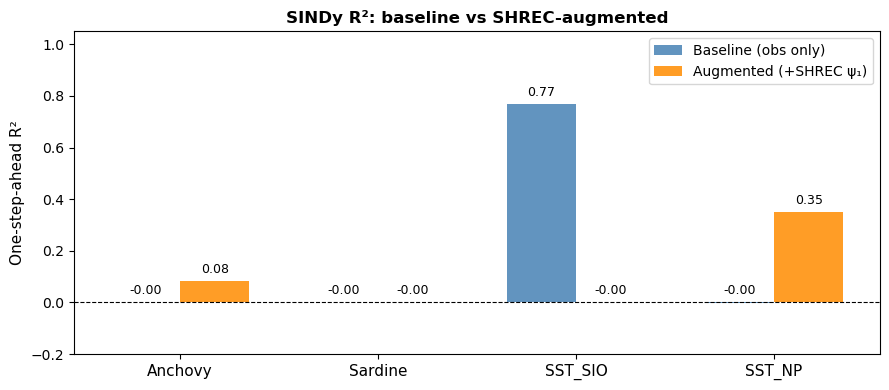

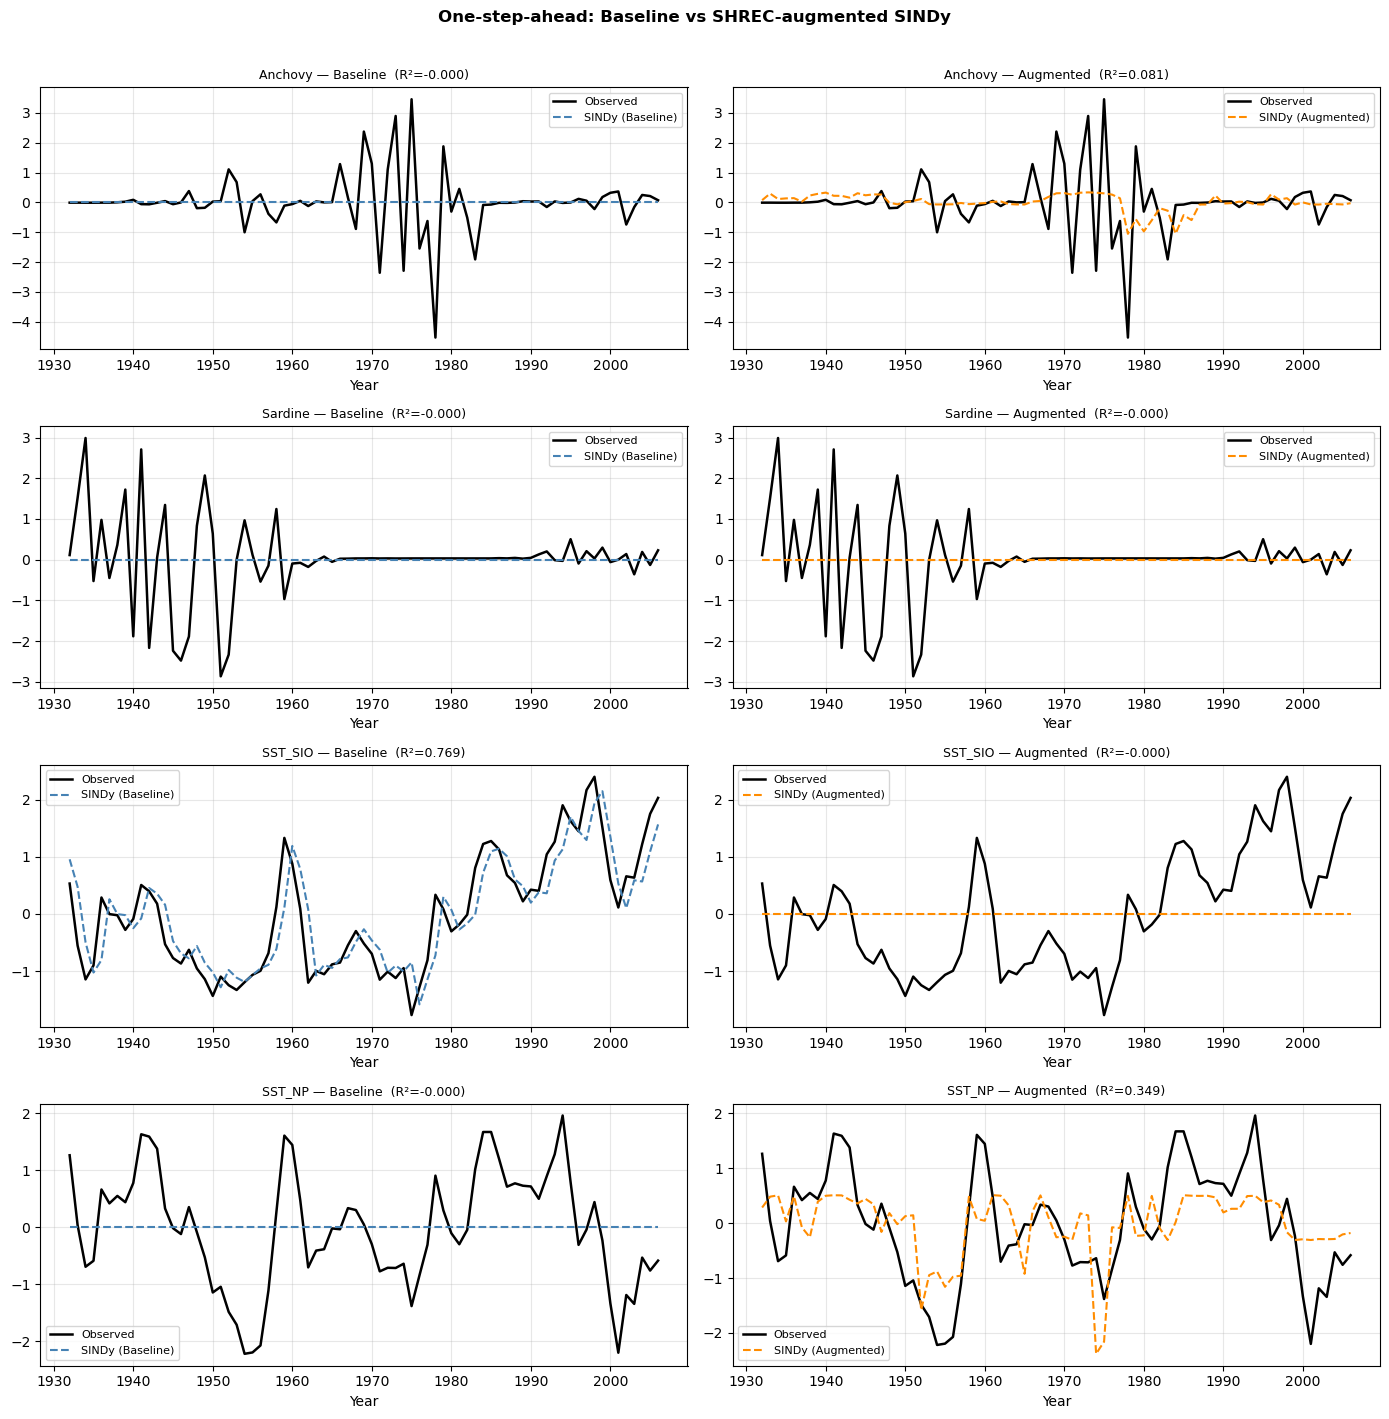

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 3 — STLS with found λ, then compare baseline vs augmented
# ══════════════════════════════════════════════════════════════════════════════

Xi_base, lamb_base, _ = sparsifyDynamics(Theta_base, Xtp1_base, top_pct=TOP_PCT_BASE)
Xi_aug,  lamb_aug,  _ = sparsifyDynamics(Theta_aug,  Xtp1_aug,  top_pct=TOP_PCT_AUG)

pred_base = Theta_base @ Xi_base
pred_aug  = Theta_aug  @ Xi_aug

# ── Print discovered equations ─────────────────────────────────────────────
for label, Xi, feat, lab in [
    ("BASELINE",  Xi_base, feat_base, lab_base),
    ("AUGMENTED", Xi_aug,  feat_aug,  lab_aug),
]:
    print(f"\n{'═'*62}")
    print(f"  {label}  —  Discovered equations  x(t+1) = F(x(t))")
    print(f"{'═'*62}")
    for i, name in enumerate(lab):
        terms = [f'{Xi[j,i]:+.4f}·{feat[j]}'
                 for j in range(len(feat)) if abs(Xi[j, i]) > 1e-8]
        print(f"  {name}(t+1) = {' '.join(terms) if terms else '0'}")

# ── R² for the 4 observed variables ───────────────────────────────────────
r2_base_vals = [r_squared(Xtp1_base[:, i], pred_base[:, i]) for i in range(4)]
r2_aug_vals  = [r_squared(Xtp1_aug[:,  i], pred_aug[:,  i]) for i in range(4)]

print(f"\n{'─'*50}")
print(f"  R² comparison  (one-step-ahead, 4 observed variables)")
print(f"  {'Variable':12s}  {'Baseline':>10}  {'Augmented':>10}  {'Δ':>8}")
print(f"  {'─'*46}")
for i, v in enumerate(obs_long):
    delta = r2_aug_vals[i] - r2_base_vals[i]
    arrow = '▲' if delta > 0.01 else ('▽' if delta < -0.01 else '≈')
    print(f"  {v:12s}  {r2_base_vals[i]:10.3f}  {r2_aug_vals[i]:10.3f}  {arrow} {delta:+.3f}")

# ── Bar chart ──────────────────────────────────────────────────────────────
colors_obs = ['steelblue', 'tomato', 'seagreen', 'darkorange']
x     = np.arange(4)
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - width/2, r2_base_vals, width, label='Baseline (obs only)',   color='steelblue',  alpha=0.85)
b2 = ax.bar(x + width/2, r2_aug_vals,  width, label='Augmented (+SHREC ψ₁)', color='darkorange', alpha=0.85)

for bars, vals in [(b1, r2_base_vals), (b2, r2_aug_vals)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(obs_long, fontsize=11)
ax.set_ylabel('One-step-ahead R²', fontsize=11)
ax.set_title('SINDy R²: baseline vs SHREC-augmented', fontsize=12, fontweight='bold')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.legend(fontsize=10); ax.set_ylim(-0.2, 1.05)
plt.tight_layout()
plt.savefig('sindy_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Trajectory plots ───────────────────────────────────────────────────────
t_plot = time_axis[3:]   # time_axis is length 76; after [:-1]/[1:] → 75 steps; trim 2 for obs alignment
# correct alignment: time_axis = years[2:] (76 pts), Xtp1 = rows 1..75 → years[3:]
t_plot = years[3:]

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
for i, (vname, c) in enumerate(zip(obs_long, colors_obs)):
    for j, (pred, Xtp1, lab, col) in enumerate([
        (pred_base, Xtp1_base, 'Baseline',  'steelblue'),
        (pred_aug,  Xtp1_aug,  'Augmented', 'darkorange'),
    ]):
        ax = axes[i, j]
        r2v = r2_base_vals[i] if j == 0 else r2_aug_vals[i]
        ax.plot(t_plot, Xtp1[:, i], color='k',  lw=1.8, label='Observed')
        ax.plot(t_plot, pred[:, i], color=col, lw=1.5, ls='--', label=f'SINDy ({lab})')
        ax.set_title(f'{vname} — {lab}  (R²={r2v:.3f})', fontsize=9)
        ax.set_xlabel('Year'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('One-step-ahead: Baseline vs SHREC-augmented SINDy',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sindy_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

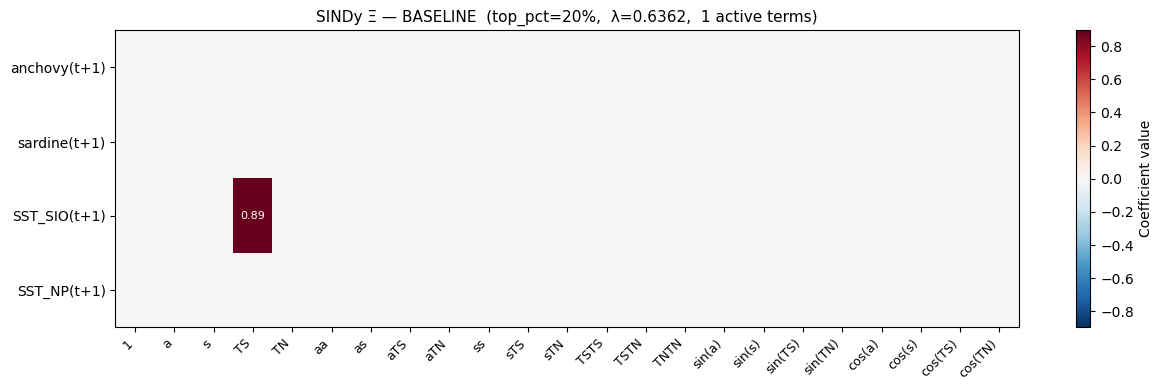

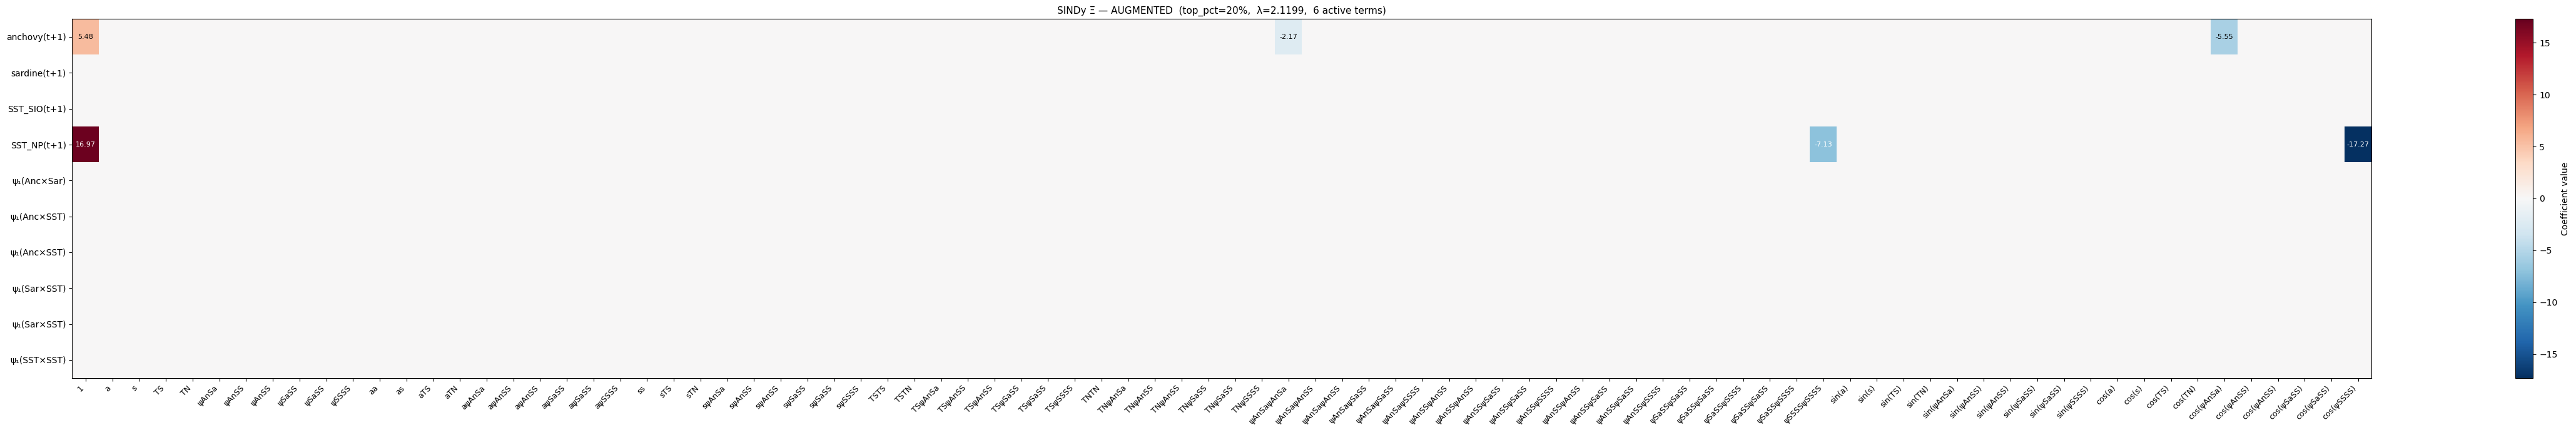

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# COEFFICIENT HEATMAPS  (one per model, same style as SINDy_sardine_anchovy)
# ══════════════════════════════════════════════════════════════════════════════

for label, Xi, feat, lamb, row_labels in [
    ("BASELINE",  Xi_base, feat_base, lamb_base,
     ['anchovy(t+1)', 'sardine(t+1)', 'SST_SIO(t+1)', 'SST_NP(t+1)']),
    ("AUGMENTED", Xi_aug,  feat_aug,  lamb_aug,
     ['anchovy(t+1)', 'sardine(t+1)', 'SST_SIO(t+1)', 'SST_NP(t+1)'] + psi_labels_long),
]:
    vmax = np.abs(Xi).max()
    if vmax < 1e-10:
        print(f'⚠ {label}: all coefficients are zero — raise TOP_PCT and re-run.')
        continue

    n_rows = Xi.shape[1]   # number of equations
    fig, ax = plt.subplots(figsize=(max(12, len(feat) * 0.55), max(4, n_rows * 0.7)))
    im = ax.imshow(Xi.T, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

    ax.set_xticks(range(len(feat)))
    ax.set_xticklabels(feat, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=10)

    for i in range(n_rows):
        for j in range(len(feat)):
            v = Xi[j, i]
            if abs(v) > 1e-10:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=8, color='white' if abs(v) > 0.4 * vmax else 'black')

    plt.colorbar(im, ax=ax, label='Coefficient value')
    n_active = int(np.sum(np.abs(Xi) > 1e-10))
    ax.set_title(
        f'SINDy Ξ — {label}  '
        f'(top_pct={TOP_PCT}%,  λ={lamb:.4f},  {n_active} active terms)',
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(f'sindy_heatmap_{label.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()